# ESP32 Battery and Performance Comparison

This notebook automatically loads and compares **any number of ESP32 CSV log files** placed in the data directory.

Supported parameters are detected dynamically from the CSV headers (e.g. battery voltage, RSSI, latency, CPU cycles, BLE attempts, etc.).


In [82]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True


In [83]:

# Directory containing CSV files
DATA_DIR = "final_csv"

# Automatically load all CSV files
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

datasets = {}

for path in csv_files:
    name = os.path.splitext(os.path.basename(path))[0]
    df = pd.read_csv(path)

    # Normalize time
    if "time_ms" in df.columns:
        df["time_s"] = (df["time_ms"] - df["time_ms"].iloc[0]) / 1000

    datasets[name] = df

print(f"Loaded datasets: {list(datasets.keys())}")


Loaded datasets: ['esp32_all_parameters', 'esp32_attackers_rerun', 'esp32_ble+wifi_attackers']


In [84]:

# Automatically detect numeric parameters (excluding time)
sample_df = next(iter(datasets.values()))
numeric_params = sample_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_params = [c for c in numeric_params if c not in ["time_ms", "time_s"]]

numeric_params


['battery_voltage',
 'rssi_dbm',
 'ble_conn_attempts',
 'prime_calc_ms',
 'cpu_cycles',
 'latency_us']

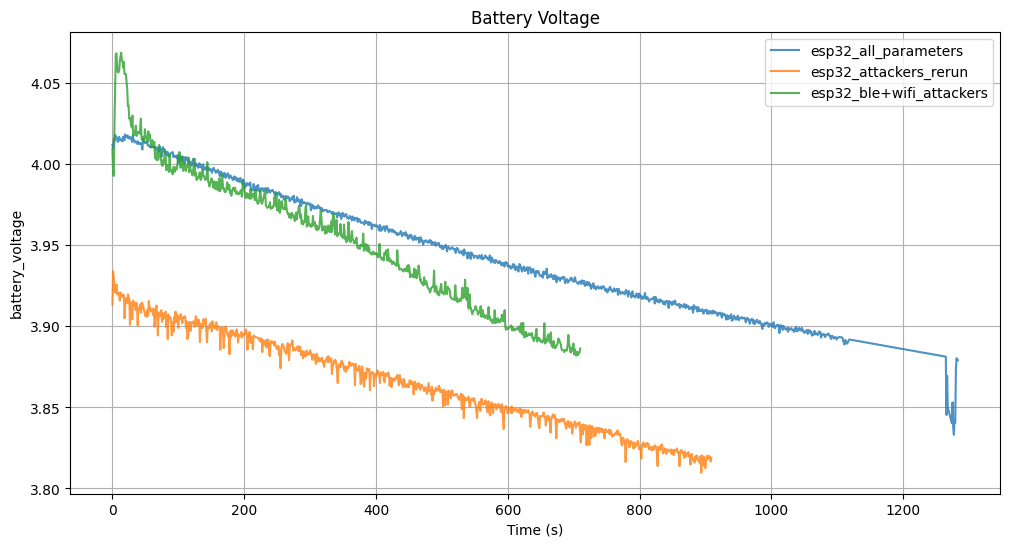

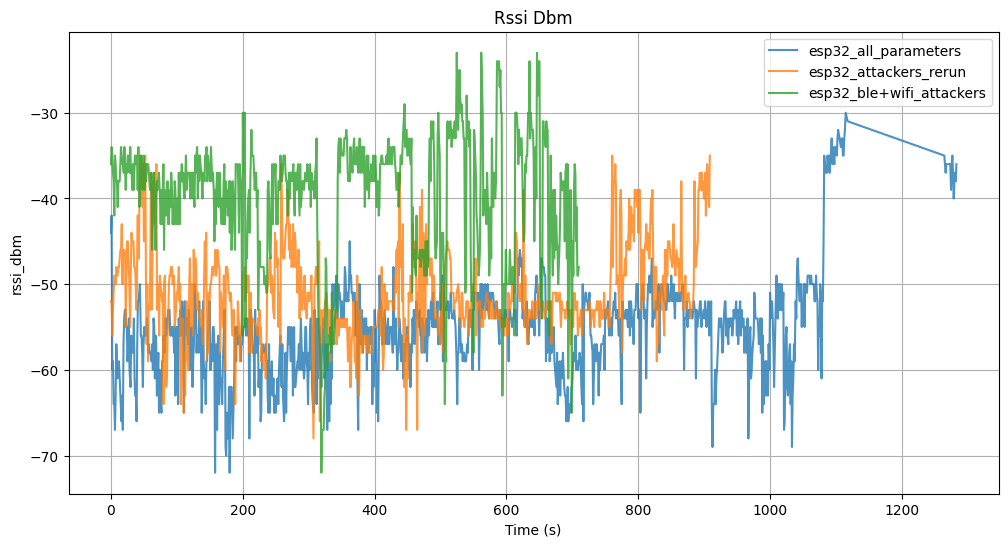

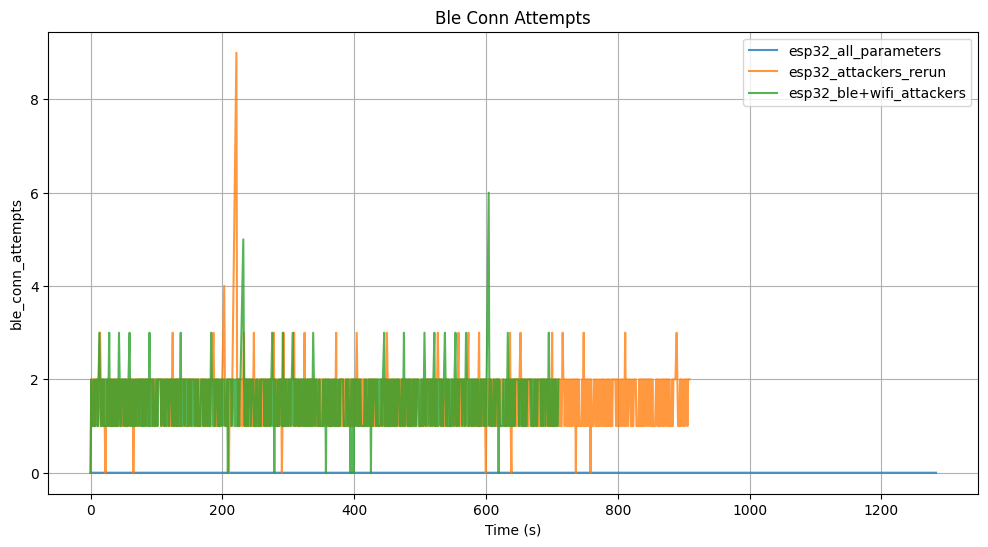

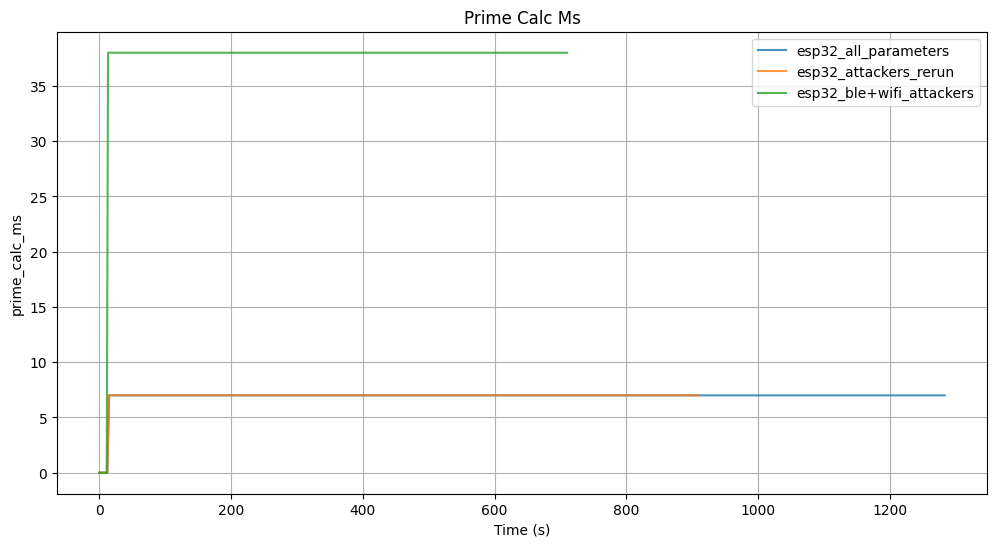

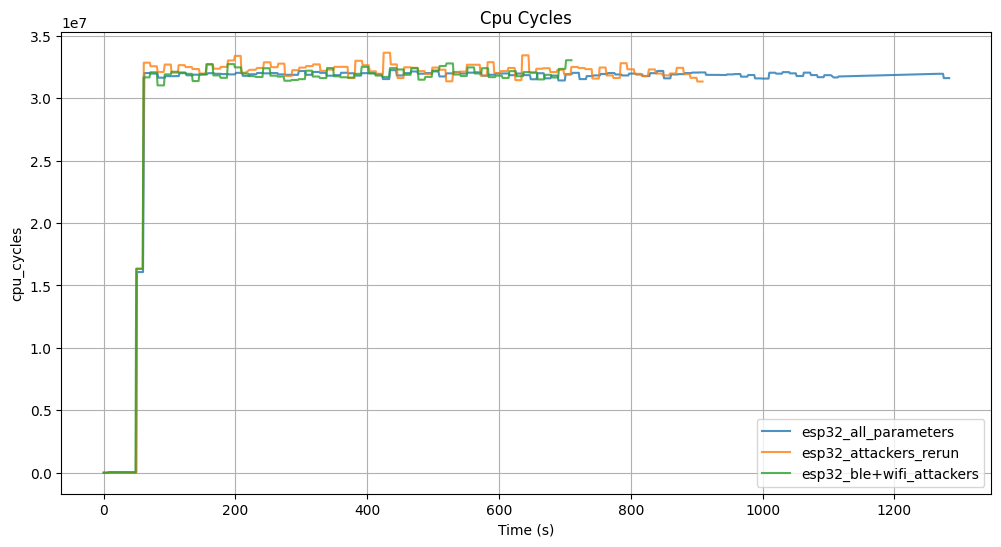

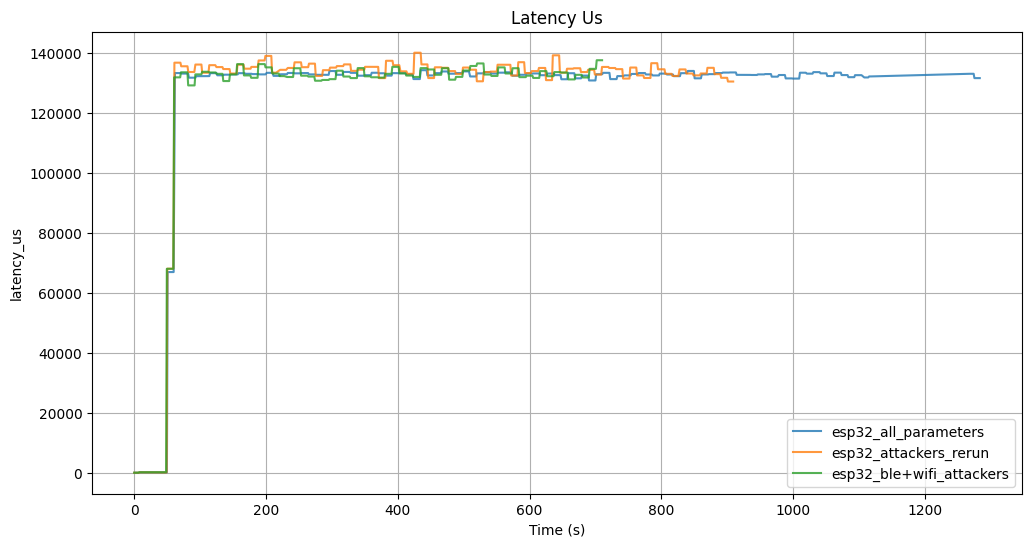

In [85]:

# Plot all numeric parameters over time
for param in numeric_params:
    plt.figure()
    for name, df in datasets.items():
        if param in df.columns:
            plt.plot(df["time_s"], df[param], label=name, alpha=0.8)

    plt.title(param.replace("_", " ").title())
    plt.xlabel("Time (s)")
    plt.ylabel(param)
    plt.legend()
    plt.show()


In [86]:

# Compute voltage drain slope if battery_voltage exists
def voltage_slope(df):
    coeffs = np.polyfit(df["time_s"], df["battery_voltage"], 1)
    return coeffs[0]

slopes = {}

for name, df in datasets.items():
    if "battery_voltage" in df.columns:
        slopes[name] = voltage_slope(df)

slopes


{'esp32_all_parameters': np.float64(-0.00011435744316150539),
 'esp32_attackers_rerun': np.float64(-0.00011002870012284461),
 'esp32_ble+wifi_attackers': np.float64(-0.00020736097808434986)}

In [87]:

# Summary statistics for all datasets
summary_rows = []

for name, df in datasets.items():
    row = {"Dataset": name}

    for param in numeric_params:
        if param in df.columns:
            row[f"{param}_mean"] = df[param].mean()

    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
summary


,Dataset,battery_voltage_mean,rssi_dbm_mean,ble_conn_attempts_mean,prime_calc_ms_mean,cpu_cycles_mean,latency_us_mean
0,esp32_all_parameters,3.946207,-55.044592,0.000000,6.913662,3.033205e+07,126383.529412
1,esp32_attackers_rerun,3.864960,-50.887574,1.570414,6.892308,3.032144e+07,126339.353846
2,esp32_ble+wifi_attackers,3.952991,-39.547112,1.579027,37.306991,2.950328e+07,122930.326748


In [88]:
def compute_discharge_rate(df):
    """
    Returns:
        slope_v_per_s : Voltage discharge rate in V/s
        slope_mv_per_hr : Voltage discharge rate in mV/hour
    """
    coeffs = np.polyfit(df["time_s"], df["battery_voltage"], 1)
    slope_v_per_s = coeffs[0]
    slope_mv_per_hr = slope_v_per_s * 1000 * 3600
    return slope_v_per_s, slope_mv_per_hr


discharge_rates = []

for name, df in datasets.items():
    if {"battery_voltage", "time_s"} <= set(df.columns):
        vps, mvph = compute_discharge_rate(df)
        discharge_rates.append({
            "Dataset": name,
            "Discharge_V_per_s": vps,
            "Discharge_mV_per_hour": mvph
        })

discharge_rates_df = pd.DataFrame(discharge_rates)
discharge_rates_df

,Dataset,Discharge_V_per_s,Discharge_mV_per_hour
0,esp32_all_parameters,-0.000114,-411.686795
1,esp32_attackers_rerun,-0.000110,-396.103320
2,esp32_ble+wifi_attackers,-0.000207,-746.499521


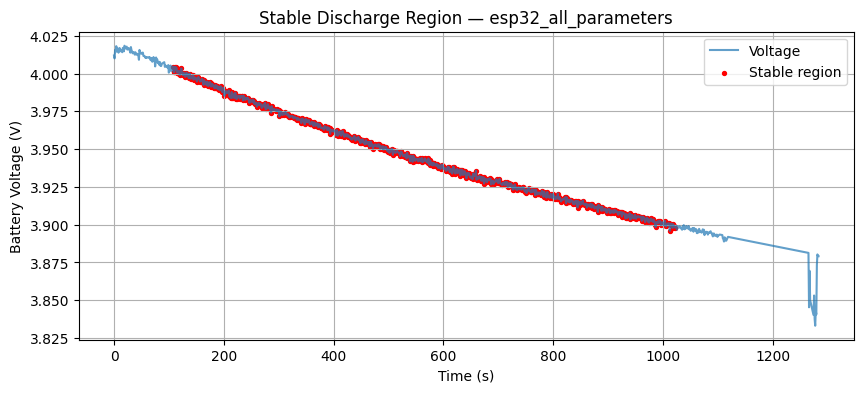

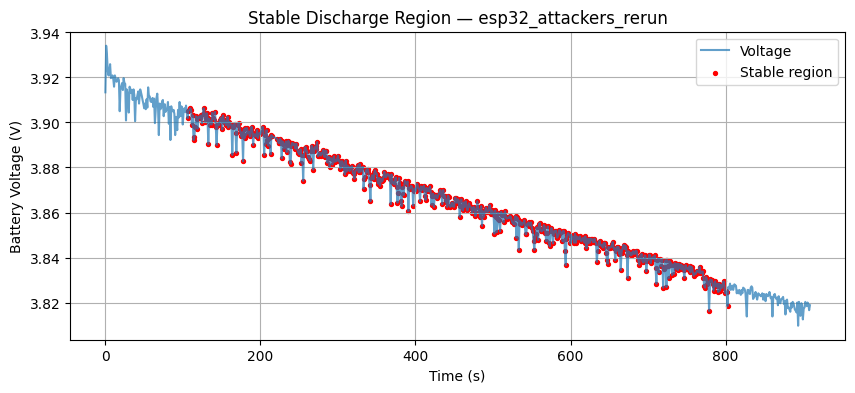

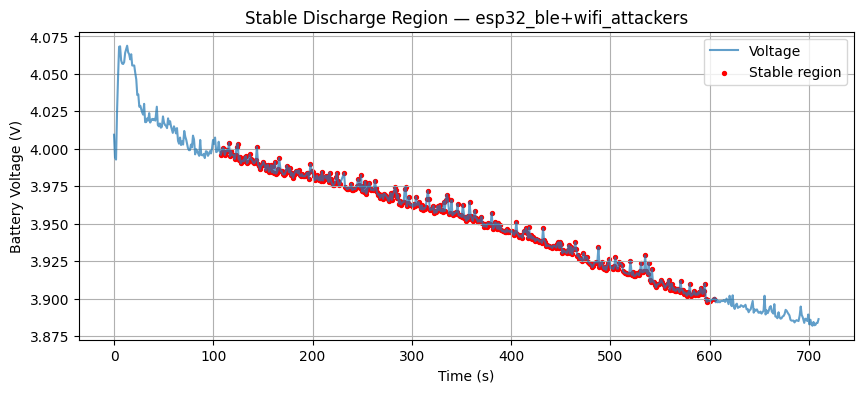

,Dataset,Stable_Discharge_V_per_s,Stable_Discharge_mV_per_hour
0,esp32_all_parameters,-0.000112,-404.775176
1,esp32_attackers_rerun,-0.000110,-394.332826
2,esp32_ble+wifi_attackers,-0.000198,-714.200441


In [89]:
# Robust voltage discharge rate using stable region with auto-relax + debug

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def compute_stable_discharge_rate(
    df,
    window=200,
    dv_threshold_mv=5,
    min_fraction=0.4,
    debug=False,
    dataset_name=""
):
    """
    Parameters
    ----------
    window : int
        Rolling window size for stability enforcement
    dv_threshold_mv : float
        Max allowed |dV/dt| in mV/s for stable region
    min_fraction : float
        Minimum fraction of samples required
    debug : bool
        Plot stable vs rejected regions
    dataset_name : str
        Label used in debug plots

    Returns
    -------
    slope_v_per_s : float or NaN
    slope_mv_per_hour : float or NaN
    """

    if not {"time_s", "battery_voltage"} <= set(df.columns):
        return np.nan, np.nan

    t = df["time_s"].values
    v = df["battery_voltage"].values

    # First derivative
    dv_dt = np.gradient(v, t)

    # Threshold in V/s
    dv_thresh_v = dv_threshold_mv / 1000.0

    # Primary stability mask
    stable_mask = np.abs(dv_dt) < dv_thresh_v

    # Rolling consistency filter
    stable_mask = (
        pd.Series(stable_mask)
        .rolling(window, center=True, min_periods=window)
        .mean()
        > 0.8
    ).values

    # Auto-relax if too strict
    if stable_mask.sum() < min_fraction * len(df):
        # Relax thresholds
        stable_mask = np.abs(dv_dt) < (2 * dv_thresh_v)

        stable_mask = (
            pd.Series(stable_mask)
            .rolling(window, center=True, min_periods=1)
            .mean()
            > 0.7
        ).values

    # Final fallback: monotonic discharge
    if stable_mask.sum() < min_fraction * len(df):
        dv = np.diff(v)
        mono = dv < 0
        stable_mask = np.concatenate([[False], mono])

    # Still insufficient → reject
    if stable_mask.sum() < 10:
        return np.nan, np.nan

    # Linear fit on stable region only
    coeffs = np.polyfit(t[stable_mask], v[stable_mask], 1)
    slope_v_per_s = coeffs[0]
    slope_mv_per_hour = slope_v_per_s * 1000 * 3600

    # Debug visualization
    if debug:
        plt.figure(figsize=(10, 4))
        plt.plot(t, v, label="Voltage", alpha=0.7)
        plt.scatter(
            t[stable_mask],
            v[stable_mask],
            color="red",
            s=8,
            label="Stable region"
        )
        plt.title(f"Stable Discharge Region — {dataset_name}")
        plt.xlabel("Time (s)")
        plt.ylabel("Battery Voltage (V)")
        plt.legend()
        plt.grid(True)
        plt.show()

    return slope_v_per_s, slope_mv_per_hour


# Apply to all datasets
discharge_rates = []

for name, df in datasets.items():
    vps, mvph = compute_stable_discharge_rate(
        df,
        debug=True,          # set False to disable plots
        dataset_name=name
    )

    discharge_rates.append({
        "Dataset": name,
        "Stable_Discharge_V_per_s": vps,
        "Stable_Discharge_mV_per_hour": mvph
    })

stable_discharge_df = pd.DataFrame(discharge_rates)
stable_discharge_df